# Arccos Golf Data Analysis
Exploring round, strokes gained, and shot data from Arccos + GHIN handicap history.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

con = duckdb.connect("arccos.duckdb", read_only=True)
print("Connected! Tables:")
for t in con.execute("SHOW TABLES").fetchall():
    count = con.execute(f"SELECT COUNT(*) FROM {t[0]}").fetchone()[0]
    print(f"  {t[0]}: {count:,} rows")

Connected! Tables:
  clubs: 28 rows
  course_hole_tees: 1,890 rows
  course_holes: 387 rows
  course_tees: 112 rows
  courses: 24 rows
  ghin_handicap_history: 248 rows
  ghin_hole_scores: 1,440 rows
  ghin_scores: 477 rows
  holes: 3,522 rows
  player_profile: 1 rows
  rounds: 202 rows
  sga_analysis: 2,020 rows
  sga_by_distance: 32,320 rows
  sga_by_hole_shape: 6,060 rows
  sga_by_terrain: 8,080 rows
  sga_putting_by_hole: 34,970 rows
  shots: 15,991 rows
  weather_cache: 201 rows


## 1. Handicap Index Over Time

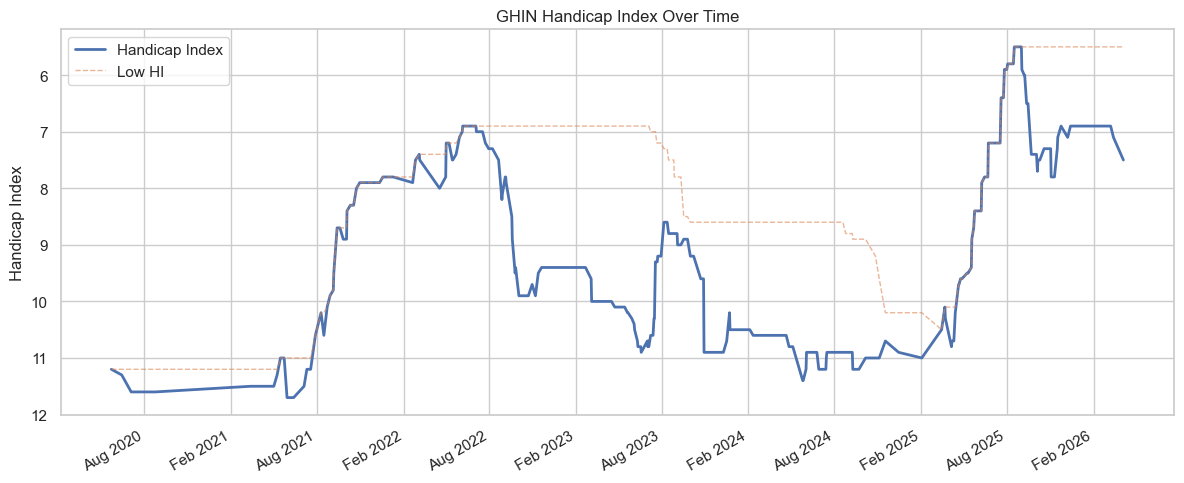

Current: 7.5  |  Low: 5.5  |  High: 11.7


In [22]:
hcp = con.execute("""
    SELECT rev_date, handicap_index, low_hi
    FROM ghin_handicap_history
    WHERE handicap_index < 900
    ORDER BY rev_date
""").df()

fig, ax = plt.subplots()
ax.plot(hcp["rev_date"], hcp["handicap_index"], linewidth=2, label="Handicap Index")
ax.plot(hcp["rev_date"], hcp["low_hi"], linewidth=1, linestyle="--", alpha=0.6, label="Low HI")
ax.set_title("GHIN Handicap Index Over Time")
ax.set_ylabel("Handicap Index")
ax.invert_yaxis()
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Current: {hcp['handicap_index'].iloc[-1]}  |  Low: {hcp['low_hi'].min()}  |  High: {hcp['handicap_index'].max()}")

## 2. Score vs Par Over Time (18-hole rounds)

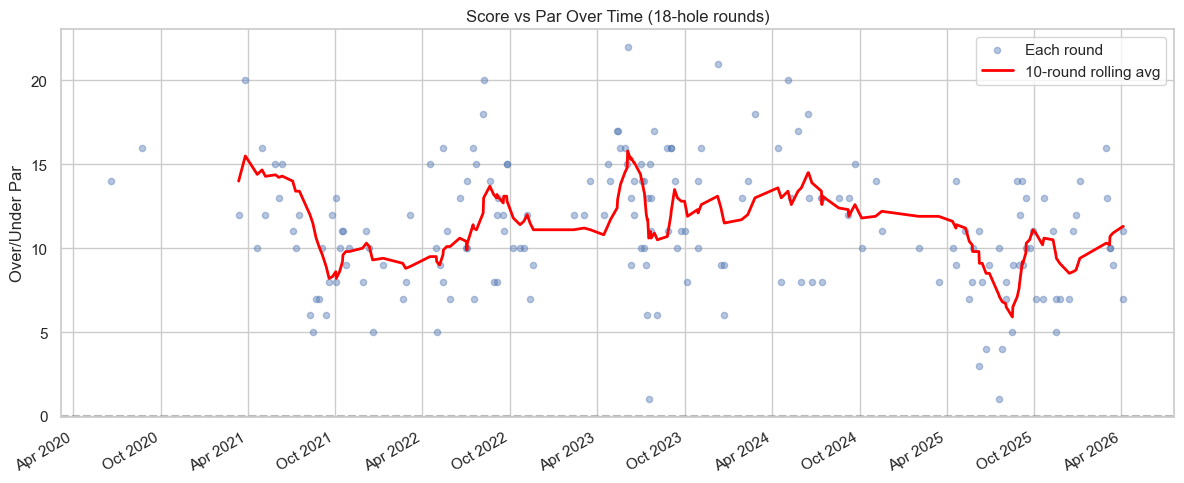

Rounds: 184  |  Best: +1  |  Worst: +22  |  Avg: +11.2


In [23]:
rounds = con.execute("""
    SELECT start_time::DATE as date, course_name, par, over_under, num_holes,
           avg_temp_f, avg_wind_mph, total_precip_in
    FROM rounds
    WHERE num_holes = 18
    ORDER BY start_time
""").df()

rounds["score"] = rounds["par"] + rounds["over_under"]
rounds["rolling_avg"] = rounds["over_under"].rolling(10, min_periods=3).mean()

fig, ax = plt.subplots()
ax.scatter(rounds["date"], rounds["over_under"], alpha=0.4, s=20, label="Each round")
ax.plot(rounds["date"], rounds["rolling_avg"], color="red", linewidth=2, label="10-round rolling avg")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Score vs Par Over Time (18-hole rounds)")
ax.set_ylabel("Over/Under Par")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Rounds: {len(rounds)}  |  Best: {rounds['over_under'].min():+d}  |  "
      f"Worst: {rounds['over_under'].max():+d}  |  Avg: {rounds['over_under'].mean():+.1f}")

## 3. Strokes Gained Breakdown

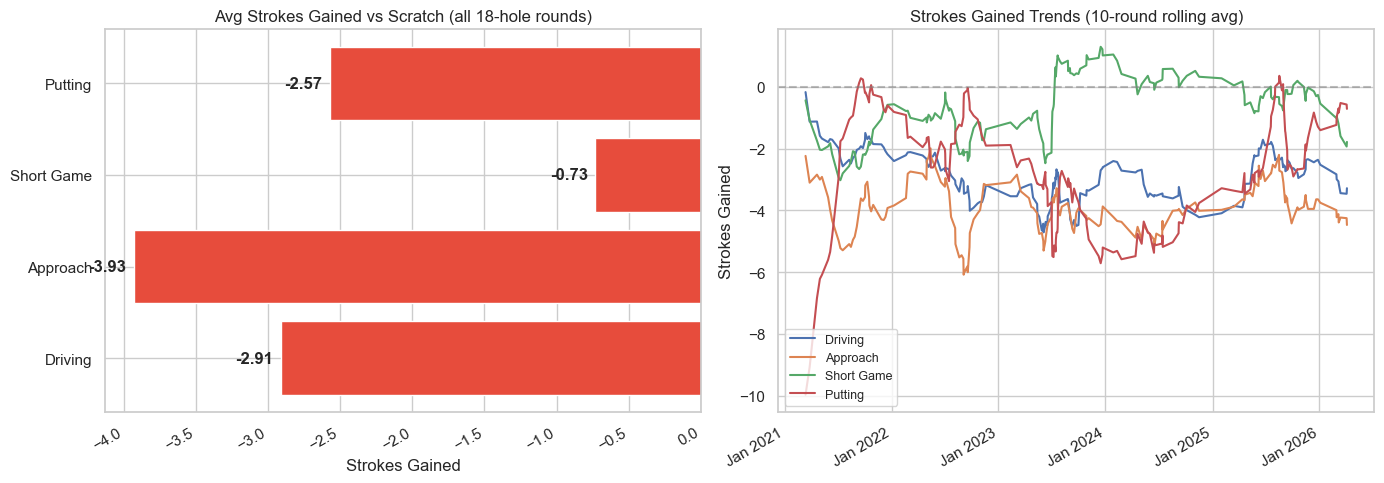

In [24]:
sga = con.execute("""
    SELECT r.start_time::DATE as date,
           s.drive_sga, s.approach_sga, s.short_game_sga, s.putting_sga
    FROM sga_analysis s
    JOIN rounds r ON s.round_id = r.round_id
    WHERE s.goal_hcp = 0 AND r.num_holes = 18
    ORDER BY r.start_time
""").df()

categories = ["drive_sga", "approach_sga", "short_game_sga", "putting_sga"]
labels = ["Driving", "Approach", "Short Game", "Putting"]

# Average strokes gained by category
avgs = [sga[c].mean() for c in categories]
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in avgs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of averages
axes[0].barh(labels, avgs, color=colors)
axes[0].axvline(x=0, color="gray", linewidth=0.8)
axes[0].set_title("Avg Strokes Gained vs Scratch (all 18-hole rounds)")
axes[0].set_xlabel("Strokes Gained")
for i, v in enumerate(avgs):
    axes[0].text(v + 0.05 if v >= 0 else v - 0.05, i, f"{v:.2f}",
                 va="center", ha="left" if v >= 0 else "right", fontweight="bold")

# Trend over time
window = 10
for c, label in zip(categories, labels):
    axes[1].plot(sga["date"], sga[c].rolling(window, min_periods=3).mean(), label=label, linewidth=1.5)
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title(f"Strokes Gained Trends ({window}-round rolling avg)")
axes[1].set_ylabel("Strokes Gained")
axes[1].legend(loc="lower left", fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 4. GIR & Fairway Hit Rates Over Time

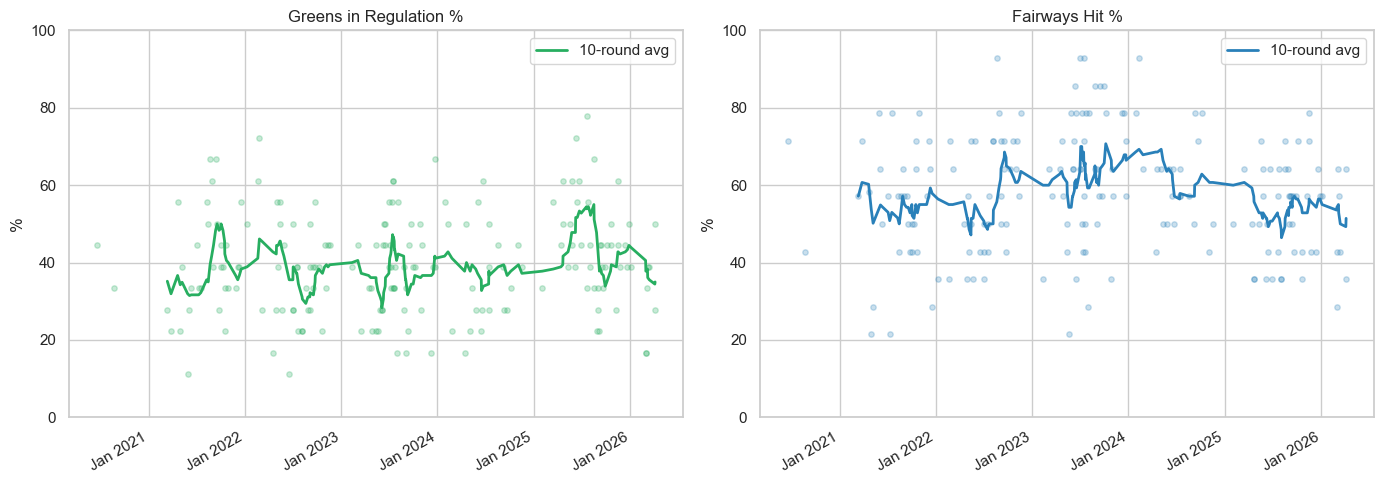

Avg GIR: 39.5%  |  Avg FWY: 57.7%  |  Avg putts/round: 33.7  |  Avg 3-putts/round: 1.7


In [25]:
stats = con.execute("""
    SELECT r.start_time::DATE as date,
           s.gir_hit, s.gir_total,
           s.fairways_hit, s.fairways_total,
           s.total_putts, s.three_putts
    FROM sga_analysis s
    JOIN rounds r ON s.round_id = r.round_id
    WHERE s.goal_hcp = 0 AND r.num_holes = 18
    ORDER BY r.start_time
""").df()

stats["gir_pct"] = (stats["gir_hit"] / stats["gir_total"] * 100)
stats["fwy_pct"] = (stats["fairways_hit"] / stats["fairways_total"] * 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

window = 10
for ax, col, title, color in [
    (axes[0], "gir_pct", "Greens in Regulation %", "#27ae60"),
    (axes[1], "fwy_pct", "Fairways Hit %", "#2980b9"),
]:
    ax.scatter(stats["date"], stats[col], alpha=0.25, s=15, color=color)
    ax.plot(stats["date"], stats[col].rolling(window, min_periods=3).mean(),
            color=color, linewidth=2, label=f"{window}-round avg")
    ax.set_title(title)
    ax.set_ylabel("%")
    ax.set_ylim(0, 100)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Avg GIR: {stats['gir_pct'].mean():.1f}%  |  Avg FWY: {stats['fwy_pct'].mean():.1f}%  |  "
      f"Avg putts/round: {stats['total_putts'].mean():.1f}  |  Avg 3-putts/round: {stats['three_putts'].mean():.1f}")

## 5. Scoring by Course

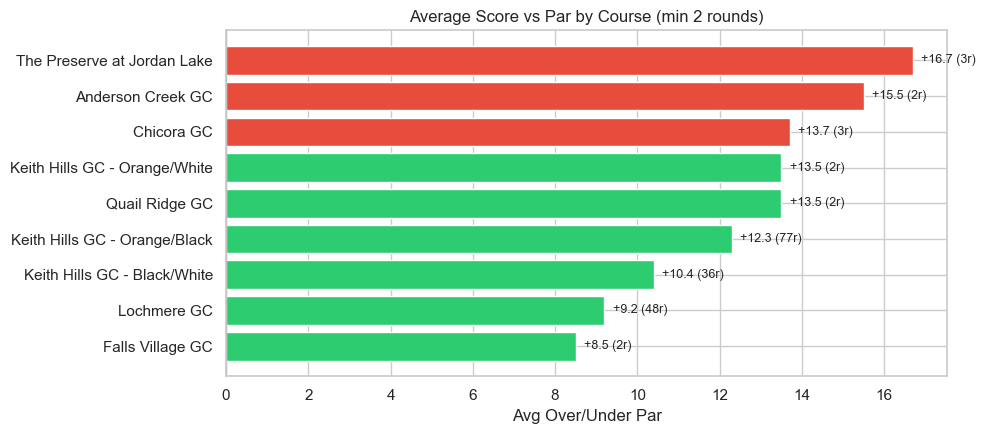

In [26]:
by_course = con.execute("""
    SELECT course_name,
           COUNT(*) as rounds,
           ROUND(AVG(over_under), 1) as avg_over_under,
           MIN(over_under) as best,
           MAX(over_under) as worst
    FROM rounds
    WHERE num_holes = 18
    GROUP BY course_name
    HAVING COUNT(*) >= 2
    ORDER BY avg_over_under
""").df()

colors = ["#2ecc71" if v <= by_course["avg_over_under"].median() else "#e74c3c" for v in by_course["avg_over_under"]]

fig, ax = plt.subplots(figsize=(10, max(4, len(by_course) * 0.5)))
bars = ax.barh(by_course["course_name"], by_course["avg_over_under"], color=colors)
ax.axvline(x=0, color="gray", linewidth=0.8)
ax.set_title("Average Score vs Par by Course (min 2 rounds)")
ax.set_xlabel("Avg Over/Under Par")
for i, row in by_course.iterrows():
    ax.text(row["avg_over_under"] + 0.2, i, f"{row['avg_over_under']:+.1f} ({row['rounds']}r)",
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Weather Impact on Scoring

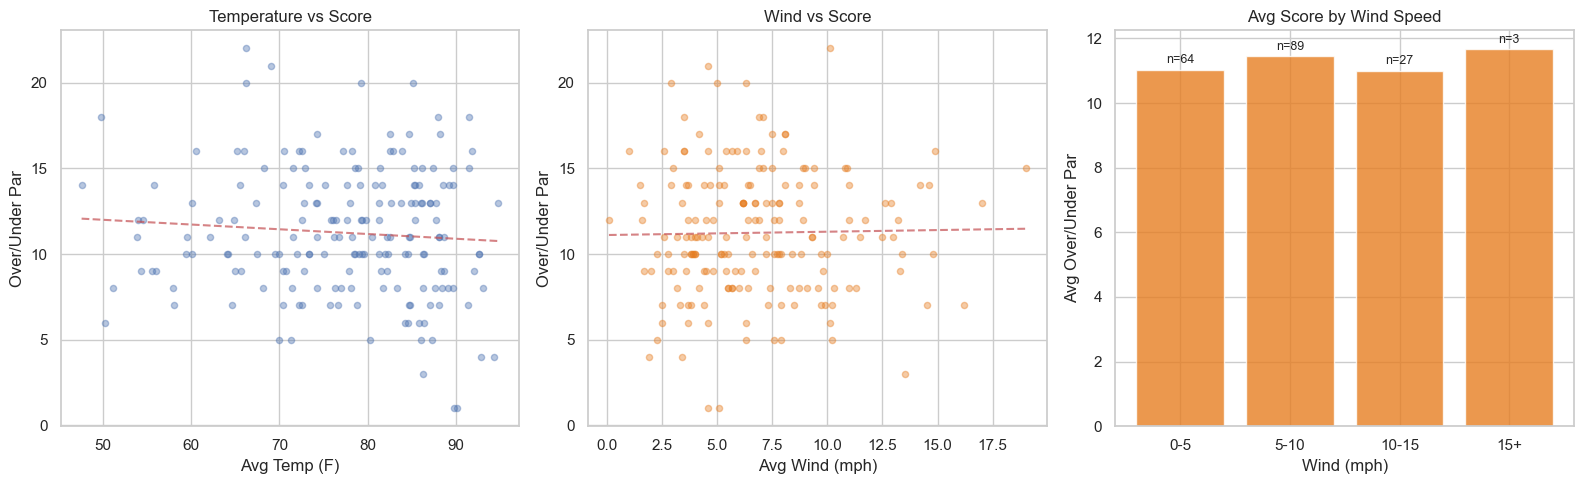

In [27]:
import numpy as np

wx = rounds.dropna(subset=["avg_temp_f", "avg_wind_mph"]).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Temperature vs score
axes[0].scatter(wx["avg_temp_f"], wx["over_under"], alpha=0.4, s=20)
z = np.polyfit(wx["avg_temp_f"], wx["over_under"], 1)
p = np.poly1d(z)
axes[0].plot(sorted(wx["avg_temp_f"]), p(sorted(wx["avg_temp_f"])), "r--", alpha=0.7)
axes[0].set_title("Temperature vs Score")
axes[0].set_xlabel("Avg Temp (F)")
axes[0].set_ylabel("Over/Under Par")

# Wind vs score
axes[1].scatter(wx["avg_wind_mph"], wx["over_under"], alpha=0.4, s=20, color="#e67e22")
z2 = np.polyfit(wx["avg_wind_mph"], wx["over_under"], 1)
p2 = np.poly1d(z2)
axes[1].plot(sorted(wx["avg_wind_mph"]), p2(sorted(wx["avg_wind_mph"])), "r--", alpha=0.7)
axes[1].set_title("Wind vs Score")
axes[1].set_xlabel("Avg Wind (mph)")
axes[1].set_ylabel("Over/Under Par")

# Wind buckets
wx["wind_bucket"] = pd.cut(wx["avg_wind_mph"], bins=[0, 5, 10, 15, 50], labels=["0-5", "5-10", "10-15", "15+"])
wind_avg = wx.groupby("wind_bucket", observed=True)["over_under"].agg(["mean", "count"]).reset_index()
axes[2].bar(wind_avg["wind_bucket"].astype(str), wind_avg["mean"], color="#e67e22", alpha=0.8)
for i, row in wind_avg.iterrows():
    axes[2].text(i, row["mean"] + 0.2, f"n={row['count']}", ha="center", fontsize=9)
axes[2].set_title("Avg Score by Wind Speed")
axes[2].set_xlabel("Wind (mph)")
axes[2].set_ylabel("Avg Over/Under Par")

plt.tight_layout()
plt.show()

## 7. Putting Analysis

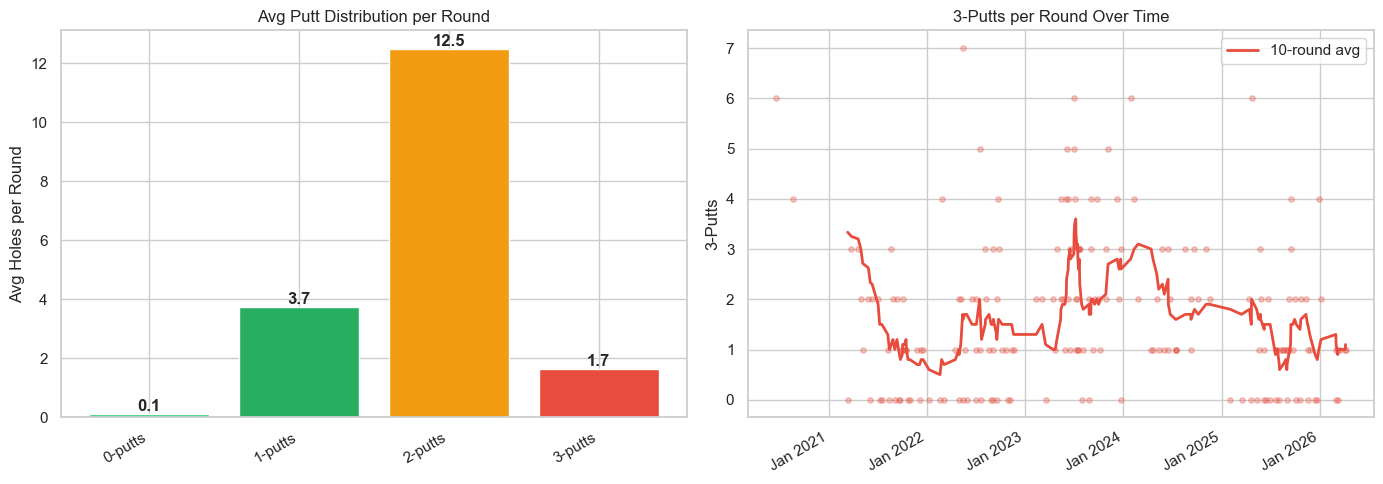

Avg putts/round: 33.7  |  Avg 1-putts: 3.7  |  Avg 3-putts: 1.7


In [28]:
putts = con.execute("""
    SELECT r.start_time::DATE as date,
           s.total_putts, s.one_putts, s.two_putts, s.three_putts, s.zero_putts,
           s.putting_sga
    FROM sga_analysis s
    JOIN rounds r ON s.round_id = r.round_id
    WHERE s.goal_hcp = 0 AND r.num_holes = 18
    ORDER BY r.start_time
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Putt distribution
putt_avgs = {
    "0-putts": putts["zero_putts"].mean(),
    "1-putts": putts["one_putts"].mean(),
    "2-putts": putts["two_putts"].mean(),
    "3-putts": putts["three_putts"].mean(),
}
colors = ["#2ecc71", "#27ae60", "#f39c12", "#e74c3c"]
axes[0].bar(putt_avgs.keys(), putt_avgs.values(), color=colors)
axes[0].set_title("Avg Putt Distribution per Round")
axes[0].set_ylabel("Avg Holes per Round")
for i, (k, v) in enumerate(putt_avgs.items()):
    axes[0].text(i, v + 0.1, f"{v:.1f}", ha="center", fontweight="bold")

# 3-putt trend
axes[1].scatter(putts["date"], putts["three_putts"], alpha=0.3, s=15, color="#e74c3c")
axes[1].plot(putts["date"], putts["three_putts"].rolling(10, min_periods=3).mean(),
             color="#e74c3c", linewidth=2, label="10-round avg")
axes[1].set_title("3-Putts per Round Over Time")
axes[1].set_ylabel("3-Putts")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Avg putts/round: {putts['total_putts'].mean():.1f}  |  "
      f"Avg 1-putts: {putts['one_putts'].mean():.1f}  |  Avg 3-putts: {putts['three_putts'].mean():.1f}")

## 8. Scoring Distribution

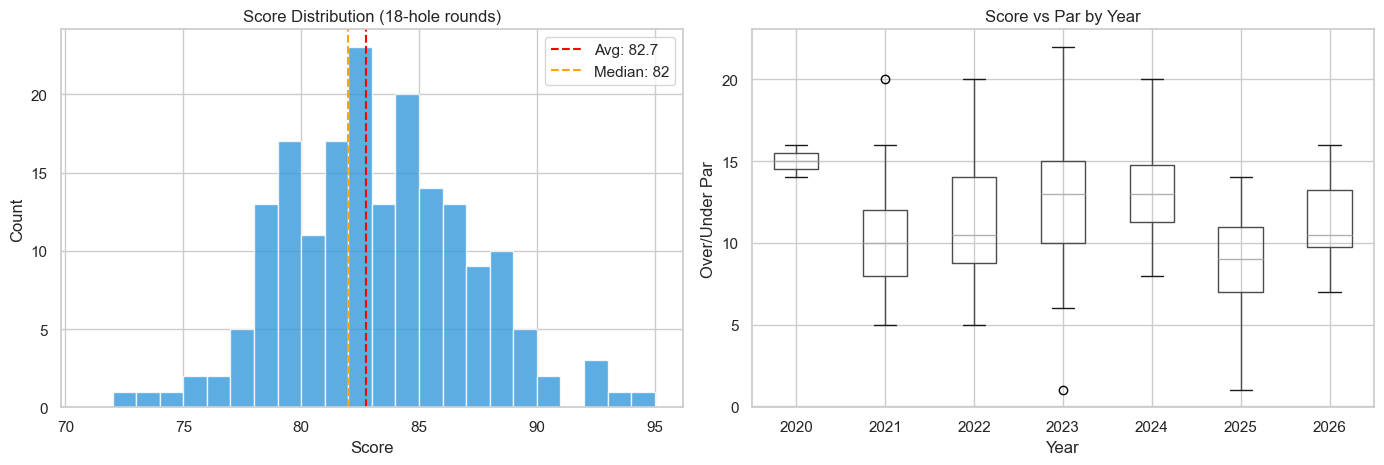

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of scores
axes[0].hist(rounds["score"], bins=range(int(rounds["score"].min())-1, int(rounds["score"].max())+2),
             color="#3498db", edgecolor="white", alpha=0.8)
axes[0].axvline(x=rounds["score"].mean(), color="red", linestyle="--", label=f"Avg: {rounds['score'].mean():.1f}")
axes[0].axvline(x=rounds["score"].median(), color="orange", linestyle="--", label=f"Median: {rounds['score'].median():.0f}")
axes[0].set_title("Score Distribution (18-hole rounds)")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Box plot by year
rounds["year"] = pd.to_datetime(rounds["date"]).dt.year
rounds.boxplot(column="over_under", by="year", ax=axes[1])
axes[1].set_title("Score vs Par by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Over/Under Par")
plt.suptitle("")  # remove auto title from boxplot

plt.tight_layout()
plt.show()

## 9. Monthly / Seasonal Trends

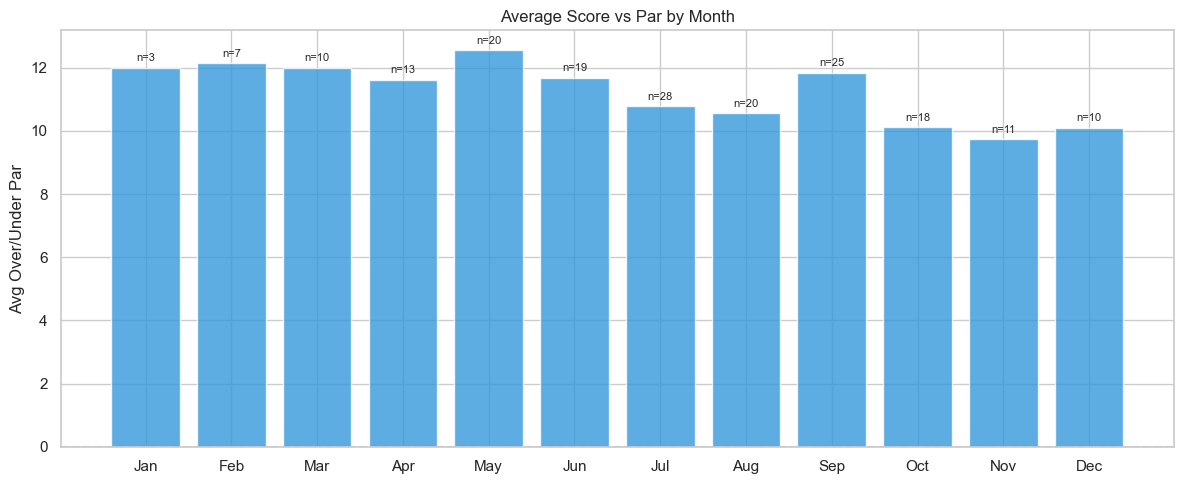

In [30]:
rounds["month"] = pd.to_datetime(rounds["date"]).dt.month
monthly = rounds.groupby("month")["over_under"].agg(["mean", "count"]).reset_index()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly["month_name"] = monthly["month"].map(lambda m: month_names[m-1])

fig, ax = plt.subplots()
bars = ax.bar(monthly["month_name"], monthly["mean"], color="#3498db", alpha=0.8)
for i, row in monthly.iterrows():
    ax.text(i, row["mean"] + 0.2, f"n={row['count']}", ha="center", fontsize=8)
ax.set_title("Average Score vs Par by Month")
ax.set_ylabel("Avg Over/Under Par")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Shot Distance by Club Type

In [ ]:
# Map shots.club_type (which is actually club_id) -> clubs.club_type (real club)
# Filter: only full swings (distance > 40% of club median) to exclude punch outs, chips, etc.
club_dist = con.execute("""
    WITH shot_clubs AS (
        SELECT c.club_type as real_club_type, s.distance
        FROM shots s
        JOIN clubs c ON s.club_type = c.club_id
        JOIN rounds r ON s.round_id = r.round_id
        WHERE s.should_ignore != 'T'
          AND s.distance > 0
          AND r.num_holes = 18
          AND c.club_type != 42  -- exclude putter
    ),
    medians AS (
        SELECT real_club_type,
               PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY distance) as median_dist
        FROM shot_clubs
        GROUP BY real_club_type
    )
    SELECT sc.real_club_type,
           ROUND(AVG(sc.distance), 0) as avg_dist,
           ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY sc.distance), 0) as median_dist,
           ROUND(MAX(sc.distance), 0) as max_dist,
           COUNT(*) as shots
    FROM shot_clubs sc
    JOIN medians m ON sc.real_club_type = m.real_club_type
    WHERE sc.distance > m.median_dist * 0.4  -- filter out punch outs / mishits
    GROUP BY sc.real_club_type
    HAVING COUNT(*) >= 5
    ORDER BY avg_dist DESC
""").df()

# Arccos club type names
club_names = {
    1: "Driver", 2: "3-Wood", 3: "5-Wood", 4: "7-Wood", 5: "Hybrid",
    6: "2-Iron", 7: "3-Iron", 8: "4-Iron", 9: "5-Iron", 10: "6-Iron",
    11: "7-Iron", 12: "8-Iron", 13: "9-Iron", 14: "PW", 15: "GW",
    16: "SW", 17: "LW", 35: "Putter",
    42: "4-Hybrid", 43: "5-Hybrid", 44: "6-Hybrid", 45: "7-Hybrid",
}
club_dist["club_name"] = club_dist["real_club_type"].map(club_names).fillna(club_dist["real_club_type"].astype(str))

fig, ax = plt.subplots(figsize=(12, max(4, len(club_dist) * 0.45)))
bars = ax.barh(club_dist["club_name"], club_dist["avg_dist"], color="#3498db", alpha=0.8)
for i, row in club_dist.iterrows():
    idx = club_dist.index.get_loc(i)
    ax.text(row["avg_dist"] + 2, idx,
            f"{row['avg_dist']:.0f} avg / {row['median_dist']:.0f} med (n={row['shots']})",
            va="center", fontsize=9)
ax.set_title("Club Distances (full swings only, punch outs filtered)")
ax.set_xlabel("Avg Distance (yards)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
### Next Steps
- **Shot maps**: Plot GPS coordinates of tee shots on your most-played holes
- **Strokes gained by distance bucket**: Where do approach shots hurt the most?
- **Scoring by tee box**: Does playing further back hurt your score proportionally?
- **Practice priorities**: Rank which SGA category would save the most strokes if improved